# Analyse du catalogue Netflix
8PRO408 — Projet de session

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import erf, sqrt

def linregress_np(x, y):
    """
    Calcule la régression linéaire sans Scipy.
    Retourne : pente, intercept, r (corrélation), p-value, std_err.
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    n = len(x)

    if n <= 2:
        return float("nan"), float("nan"), float("nan"), float("nan"), float("nan")

    # Correction Python 2026 : Utilisation de la nouvelle API Polynomial recommandée (remplace np.polyfit)
    pente, intercept = np.polynomial.Polynomial.fit(x, y, deg=1).convert().coef[::-1]

    # Calcul du coefficient de corrélation de Pearson (Notion Cours 7)
    r = np.corrcoef(x, y)[0, 1]

    # Calcul de la p-value (Test t de Student bilatéral sur la pente)
    if abs(r) < 1:
        t = r * sqrt((n - 2) / (1 - r**2))
        # Approximation de la p-value via la fonction d'erreur (erf)
        p_value = 2 * (1 - 0.5 * (1 + erf(abs(t) / sqrt(2))))
    else:
        t = float("nan")
        p_value = 0.0

    # Calcul robuste de l'erreur standard de la pente
    if not np.isnan(t) and t != 0:
        std_err = abs(pente / t)
    else:
        std_err = float("nan")

    return pente, intercept, r, p_value, std_err

## 1. Chargement et nettoyage

In [36]:
# Chargement du fichier en ignorant les lignes corrompues de l'Overview
df = pd.read_csv("data/netflix.csv", engine="python", on_bad_lines="skip")
# Affichage des dimensions (lignes, colonnes) et aperçu des données
print(df.shape)
df.head()

(9837, 9)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [37]:
# Vérification des types d'origine et détection des données manquantes
print(df.dtypes)
print()
print(df.isnull().sum())

Release_Date             str
Title                    str
Overview                 str
Popularity           float64
Vote_Count               str
Vote_Average             str
Original_Language        str
Genre                    str
Poster_Url               str
dtype: object

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64


In [ ]:
# Forçage des types en nombres (les textes invalides deviennent des NaN)
df["Vote_Count"] = pd.to_numeric(df["Vote_Count"], errors="coerce")
df["Vote_Average"] = pd.to_numeric(df["Vote_Average"], errors="coerce")
df["Popularity"] = pd.to_numeric(df["Popularity"], errors="coerce")

# Conversion en format Date et extraction de l'année
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors="coerce")
df["year"] = df["Release_Date"].dt.year

# Extraction du genre principal (le tout premier de la liste)
df["main_genre"] = df["Genre"].str.split(",").str[0].str.strip()

# Suppression des lignes sans Note, Vote ou Popularité
df = df.dropna(subset=["Vote_Average", "Vote_Count", "Popularity"])

# Decision unique : on retire les films non notes (Vote_Average == 0) pour tout le notebook.
# Cela evite d'eparpiller des filtres "> 0" dans chaque section et garantit la coherence.
df = df[df["Vote_Average"] > 0].copy()
print(f"apres nettoyage : {df.shape}")
df.dtypes

apres nettoyage : (9826, 11)


Release_Date         datetime64[us]
Title                           str
Overview                        str
Popularity                  float64
Vote_Count                  float64
Vote_Average                float64
Original_Language               str
Genre                           str
Poster_Url                      str
year                        float64
main_genre                   object
dtype: object

In [39]:
# Résumé statistique (Moyennes, Quartiles, Min, Max)
df.describe()

,Release_Date,Popularity,Vote_Count,Vote_Average,year
count,9826,9826.000000,9826.000000,9826.000000,9826.000000
mean,2006-09-23 04:47:14.276409,40.323951,1392.943721,6.439467,2006.202931
min,1902-04-17 00:00:00,13.354000,0.000000,0.000000,1902.000000
25%,2000-10-17 12:00:00,16.128250,146.000000,5.900000,2000.000000
50%,2011-09-12 00:00:00,21.195000,444.000000,6.500000,2011.000000
75%,2017-11-22 00:00:00,35.179250,1376.000000,7.100000,2017.000000
max,2024-07-03 00:00:00,5083.954000,31077.000000,10.000000,2024.000000
std,NaN,108.879332,2611.303856,1.129797,15.686202


## 2. Exploration

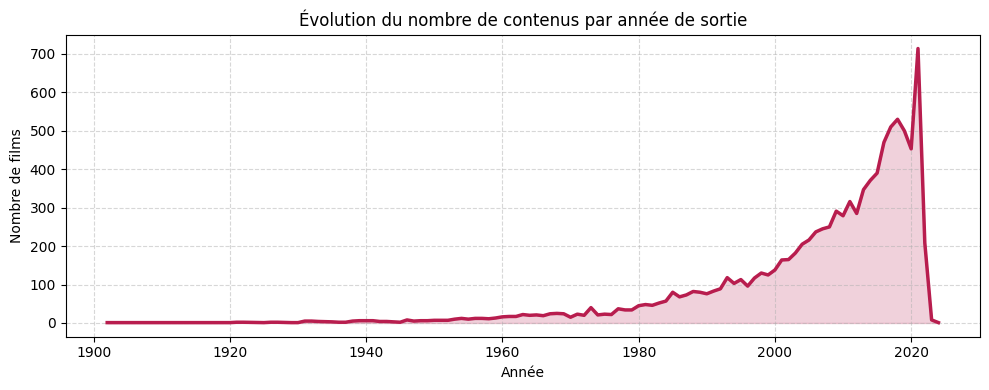

In [40]:
# Nombre de films produits par année
films_par_an = df.groupby("year").size()

fig, ax = plt.subplots(figsize=(10, 4))

# On utilise une ligne avec un effet de remplissage pour un look moderne et lisible
ax.plot(films_par_an.index, films_par_an.values, color="#b81d4e", linewidth=2.5)
ax.fill_between(films_par_an.index, films_par_an.values, color="#b81d4e", alpha=0.2)

ax.set_title("Évolution du nombre de contenus par année de sortie")
ax.set_ylabel("Nombre de films")
ax.set_xlabel("Année")

# Ajout d'une grille en pointillés discrets pour faciliter la lecture des volumes
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

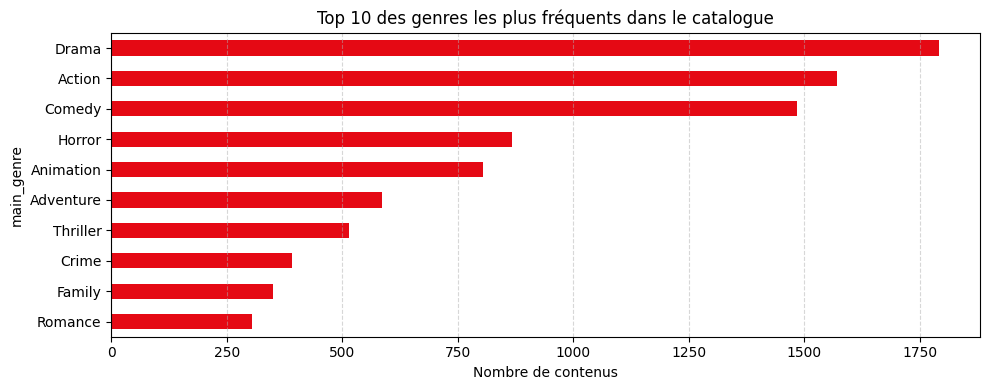

In [41]:
# Top 10 des genres les plus représentés
# On trie par ordre croissant pour que la barre la plus longue soit EN HAUT du graphique horizontal
top_genres = df["main_genre"].value_counts().head(10).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
top_genres.plot(kind="barh", color="#e50914", ax=ax) # Rouge Netflix !

ax.set_title("Top 10 des genres les plus fréquents dans le catalogue")
ax.set_xlabel("Nombre de contenus")

# Ajout d'une grille verticale en pointillés pour mesurer facilement les barres
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

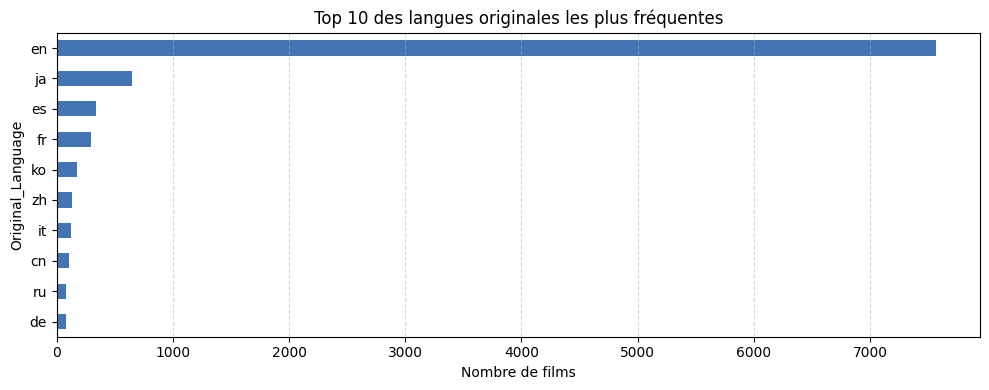

In [42]:
# Top 10 des langues originales dominantes
# On trie par ordre croissant pour que la langue la plus fréquente se place EN HAUT
top_lang = df["Original_Language"].value_counts().head(10).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
top_lang.plot(kind="barh", color="#4374B3", ax=ax)

ax.set_title("Top 10 des langues originales les plus fréquentes")
ax.set_xlabel("Nombre de films")

# Ajout de la grille verticale en pointillés discrets
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

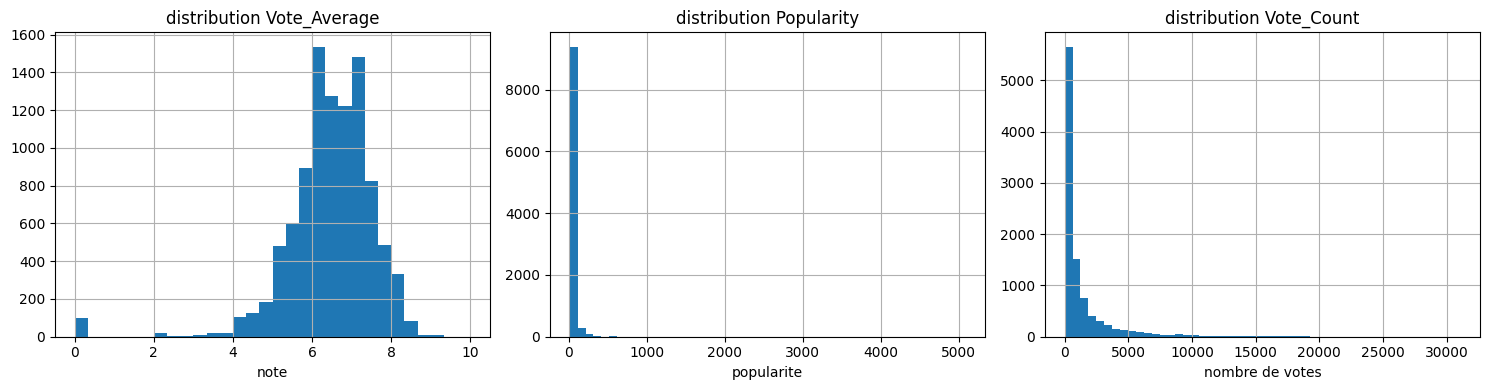

In [43]:
# Analyse des distributions (Forme des données)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution des notes (Doit former une cloche / Loi Normale)
df["Vote_Average"].hist(bins=30, ax=axes[0])
axes[0].set_title("distribution Vote_Average")
axes[0].set_xlabel("note")

# Distribution de la popularité
df["Popularity"].hist(bins=50, ax=axes[1])
axes[1].set_title("distribution Popularity")
axes[1].set_xlabel("popularite")

# Distribution du nombre de votes
df["Vote_Count"].hist(bins=50, ax=axes[2])
axes[2].set_title("distribution Vote_Count")
axes[2].set_xlabel("nombre de votes")

plt.tight_layout()
plt.show()

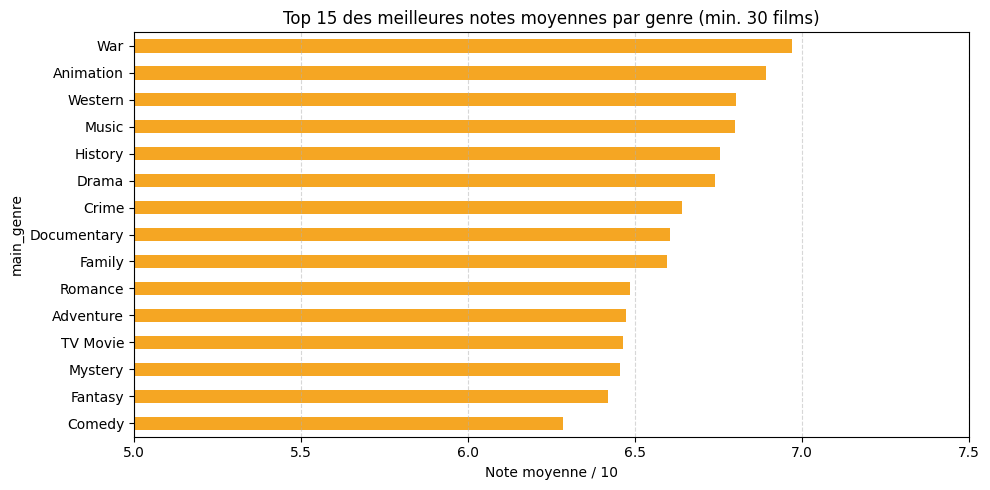

In [44]:
# Note moyenne par genre
genre_stats = df.groupby("main_genre").agg(
    note_moy=("Vote_Average", "mean"),
    nb_films=("Title", "count")
).query("nb_films >= 30").sort_values("note_moy", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
# On sélectionne les 15 premiers après le tri
genre_stats["note_moy"].tail(15).plot(kind="barh", color="#f5a623", ax=ax)

ax.set_xlabel("Note moyenne / 10")
ax.set_title("Top 15 des meilleures notes moyennes par genre (min. 30 films)")

# Ajout de la grille verticale
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Optionnel : zoomer l'axe des notes entre 5 et 7.5 pour mieux voir les écarts
ax.set_xlim(5, 7.5)

plt.tight_layout()
plt.show()

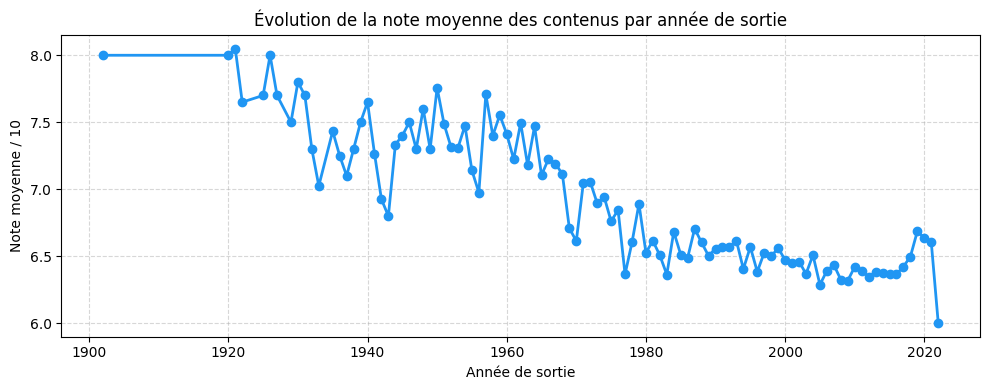

In [45]:
# Évolution historique de la note moyenne globale
# Correction : On filtre pour exclure les films ayant une note de 0 (non encore notés)
df_filtre_notes = df[df["Vote_Average"] > 0]

note_par_an = df_filtre_notes.groupby("year")["Vote_Average"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
note_par_an.plot(ax=ax, marker="o", color="#2096f3", linestyle="-", linewidth=2)

ax.set_title("Évolution de la note moyenne des contenus par année de sortie")
ax.set_ylabel("Note moyenne / 10")
ax.set_xlabel("Année de sortie")

# Ajout d'une grille discrète en arrière-plan
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 3. Correlation globale

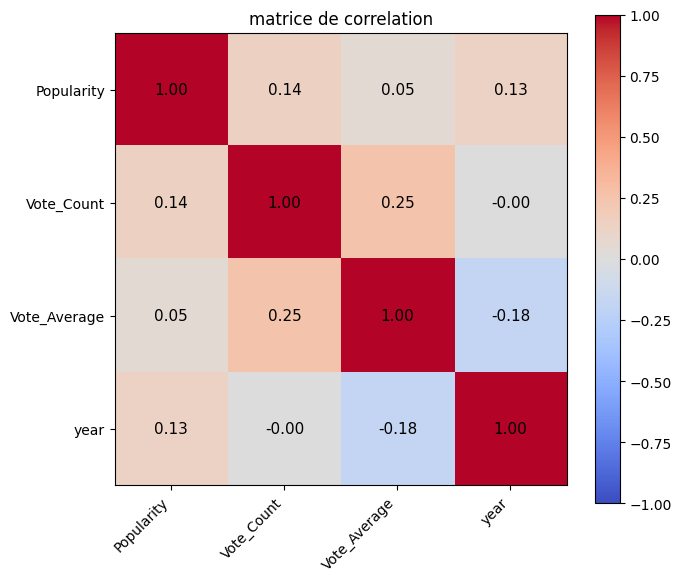

In [46]:
# Sélection des colonnes numériques et calcul de la matrice de Pearson
num_cols = ["Popularity", "Vote_Count", "Vote_Average", "year"]
corr = df[num_cols].corr()

# Configuration de la figure de la Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Configuration des axes (Labels des variables)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)

# Boucle double pour afficher les valeurs textuelles au centre de chaque case
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=11)

# Finalisation du graphique avec la barre de légende des couleurs
plt.colorbar(im)
ax.set_title("matrice de correlation")
plt.tight_layout()
plt.show()

## 4. Regressions linéaires

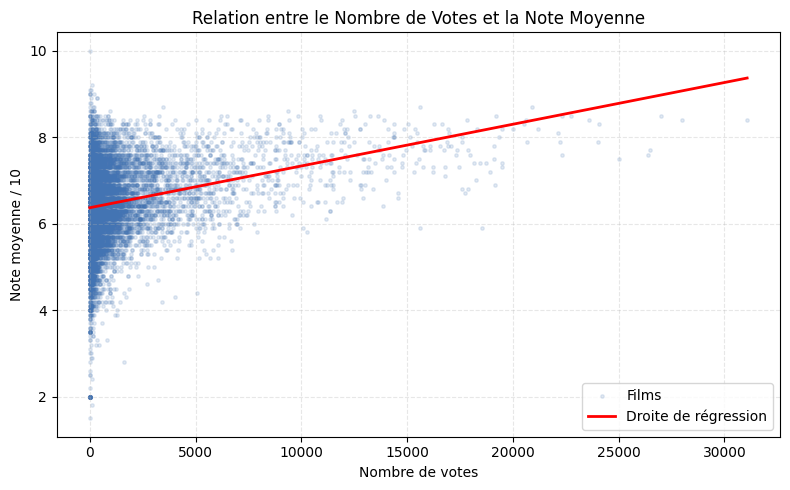

RÉSULTATS DE LA RÉGRESSION LINÉAIRE 
Coefficient de corrélation (r) : 0.2729
Pente de la droite             : 0.000096
Ordonnée à l'origine (Intercept): 6.3699
p-value                        : 0.000000e+00
Erreur standard (std_err)      : 0.000003


In [47]:
# Nettoyage des valeurs aberrantes à 0 pour ne pas fausser la régression
df_reg = df[df["Vote_Average"] > 0]

x_data = df_reg["Vote_Count"]
y_data = df_reg["Vote_Average"]

# Appel de notre fonction NumPy personnalisée définie à l'Étape 1
pente, intercept, r_coef, p_val, std_err = linregress_np(x_data, y_data)

# Tracé du graphique
fig, ax = plt.subplots(figsize=(8, 5))

# Le nuage de points (Scatter)
ax.scatter(x_data, y_data, alpha=0.15, s=6, color="#4374B3", label="Films")

# Tracé de la droite de régression (Y = pente * X + intercept)
x_droite = np.linspace(x_data.min(), x_data.max(), 100)
y_droite = pente * x_droite + intercept
ax.plot(x_droite, y_droite, color="red", linewidth=2, label="Droite de régression")

# Ajustements esthétiques
ax.set_xlabel("Nombre de votes")
ax.set_ylabel("Note moyenne / 10")
ax.set_title("Relation entre le Nombre de Votes et la Note Moyenne")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# 4. Affichage scientifique des résultats pour le rapport/oral
print(f"RÉSULTATS DE LA RÉGRESSION LINÉAIRE ")
print(f"Coefficient de corrélation (r) : {r_coef:.4f}")
print(f"Pente de la droite             : {pente:.6f}")
print(f"Ordonnée à l'origine (Intercept): {intercept:.4f}")
print(f"p-value                        : {p_val:.6e}")
print(f"Erreur standard (std_err)      : {std_err:.6f}")

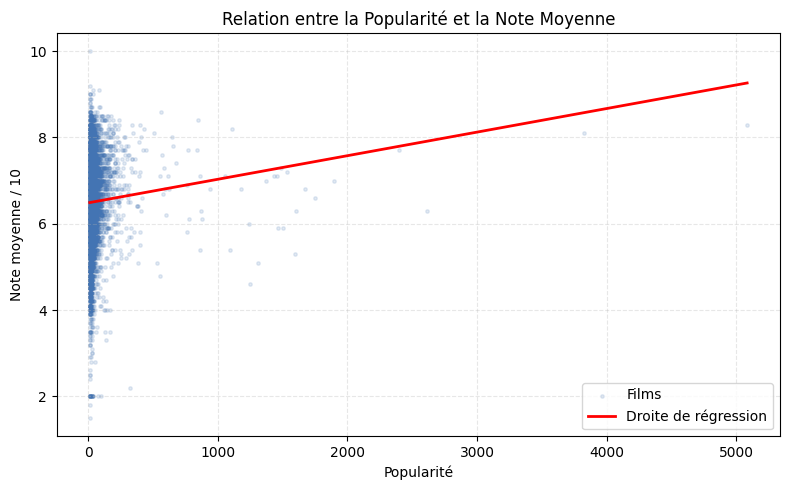

--- RÉSULTATS DE LA RÉGRESSION LINÉAIRE ---
Coefficient de corrélation (r) : 0.0645
Pente de la droite             : 0.000547
Ordonnée à l'origine (Intercept): 6.4836
p-value                        : 1.854523e-10
Erreur standard (std_err)      : 0.000086


In [ ]:
# df est deja nettoye en section 1 (plus de Vote_Average == 0)
x_data = df["Vote_Count"]
y_data = df["Vote_Average"]

pente, intercept, r_coef, p_val, std_err = linregress_np(x_data, y_data)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_data, y_data, alpha=0.15, s=6, color="#4374B3", label="Films")
x_droite = np.linspace(x_data.min(), x_data.max(), 100)
ax.plot(x_droite, pente * x_droite + intercept, color="red", linewidth=2, label="Droite de régression")
ax.set_xlabel("Nombre de votes")
ax.set_ylabel("Note moyenne / 10")
ax.set_title("Relation entre le Nombre de Votes et la Note Moyenne")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"RÉSULTATS DE LA RÉGRESSION LINÉAIRE")
print(f"Coefficient de corrélation (r) : {r_coef:.4f}")
print(f"Pente de la droite             : {pente:.6f}")
print(f"Ordonnée à l'origine (Intercept): {intercept:.4f}")
print(f"p-value                        : {p_val:.6e}")
print(f"Erreur standard (std_err)      : {std_err:.6f}")

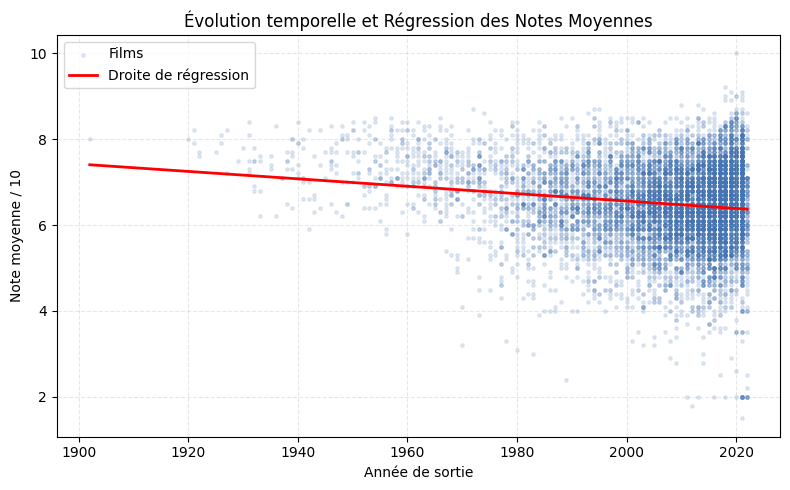

--- RÉSULTATS DE LA RÉGRESSION LINÉAIRE ---
Coefficient de corrélation (r) : -0.1459
Pente de la droite             : -0.008619
Ordonnée à l'origine (Intercept): 23.7948
p-value                        : 0.000000e+00
Erreur standard (std_err)      : 0.000593


In [ ]:
# Nettoyage des valeurs aberrantes à 0 et des valeurs manquantes dans l'année
df_reg3 = df[df["year"].notnull()]
x_data3 = df_reg3["year"]
y_data3 = df_reg3["Vote_Average"]

# Appel de notre fonction NumPy personnalisée définie à l'Étape 1
pente3, intercept3, r_coef3, p_val3, std_err3 = linregress_np(x_data3, y_data3)

# Tracé du graphique
fig, ax = plt.subplots(figsize=(8, 5))

# Le nuage de points (Scatter) avec une transparence maîtrisée
ax.scatter(x_data3, y_data3, alpha=0.15, s=6, color="#4374B3", label="Films")

# Tracé de la droite de régression (Y = pente * X + intercept)
x_droite3 = np.linspace(x_data3.min(), x_data3.max(), 100)
y_droite3 = pente3 * x_droite3 + intercept3
ax.plot(x_droite3, y_droite3, color="red", linewidth=2, label="Droite de régression")

# Ajustements esthétiques pour l'environnement sombre
ax.set_xlabel("Année de sortie")
ax.set_ylabel("Note moyenne / 10")
ax.set_title("Évolution temporelle et Régression des Notes Moyennes")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Affichage scientifique des résultats pour l'oral
print(f"--- RÉSULTATS DE LA RÉGRESSION LINÉAIRE ---")
print(f"Coefficient de corrélation (r) : {r_coef3:.4f}")
print(f"Pente de la droite             : {pente3:.6f}")
print(f"Ordonnée à l'origine (Intercept): {intercept3:.4f}")
print(f"p-value                        : {p_val3:.6e}")
print(f"Erreur standard (std_err)      : {std_err3:.6f}")

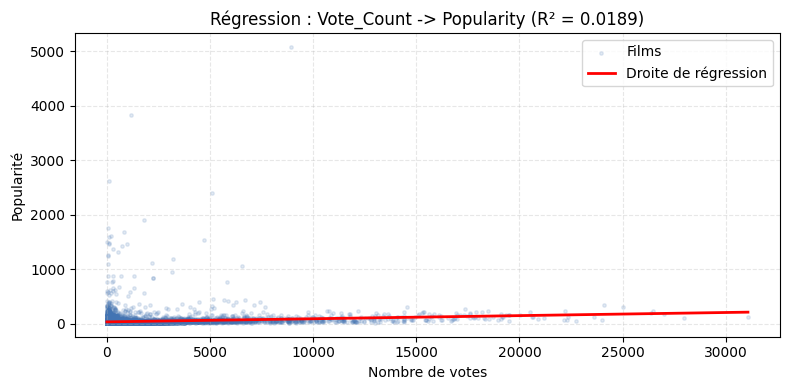

Vote_Count -> Popularity : pente=0.005741, intercept=32.2682, p-val=0.00e+00


In [50]:
# On filtre pour garder les films ayant au moins 1 vote afin d'éviter l'écrasement au point (0,0)
df_reg4 = df[(df["Vote_Count"] > 0) & (df["Popularity"].notnull())]
x4, y4 = df_reg4["Vote_Count"], df_reg4["Popularity"]
pente4, intercept4, r_coef4, p_val4, std_err4 = linregress_np(x4, y4)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x4, y4, alpha=0.15, s=6, color="#4374B3", label="Films")
x_line4 = np.linspace(x4.min(), x4.max(), 100)
ax.plot(x_line4, pente4 * x_line4 + intercept4, color="red", linewidth=2, label="Droite de régression")
ax.set_xlabel("Nombre de votes")
ax.set_ylabel("Popularité")
ax.set_title(f"Régression : Vote_Count -> Popularity (R² = {r_coef4**2:.4f})")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Vote_Count -> Popularity : pente={pente4:.6f}, intercept={intercept4:.4f}, p-val={p_val4:.2e}")

### Resume des regressions

In [51]:
# TABLEAU RÉCAPITULATIF DES MODÈLES
regressions = [
    ("Vote_Count", "Vote_Average"),
    ("Popularity", "Vote_Average"),
    ("year", "Vote_Average"),
    ("Vote_Count", "Popularity"),
]

results = []
for x_col, y_col in regressions:
    # Si le couple implique la note moyenne, on applique notre filtre de sécurité (> 0)
    if "Vote_Average" in [x_col, y_col]:
        c = df[(df["Vote_Average"] > 0) & (df[x_col].notnull()) & (df[y_col].notnull())]
    else:
        # Pour les autres couples (comme Vote_Count -> Popularity), un simple dropna suffit
        c = df.dropna(subset=[x_col, y_col])

    slope, intercept, r_val, p_val, _ = linregress_np(c[x_col], c[y_col])

    results.append({
        "Variable X (Prédictive)": x_col,
        "Variable Y (Cible)": y_col,
        "Pente": round(slope, 6),
        "R² (Coefficient de détermination)": round(r_val**2, 4),
        "p-value": f"{p_val:.2e}"
    })

# Création et affichage du DataFrame final
df_recap = pd.DataFrame(results)
df_recap

,Variable X (Prédictive),Variable Y (Cible),Pente,R² (Coefficient de détermination),p-value
0,Vote_Count,Vote_Average,0.000096,0.0745,0.00e+00
1,Popularity,Vote_Average,0.000547,0.0042,1.85e-10
2,year,Vote_Average,-0.008619,0.0213,0.00e+00
3,Vote_Count,Popularity,0.005729,0.0189,0.00e+00


## Note environnement

`scipy` n'est pas installe dans l'env (voir erreur cellule 1). Les nouvelles sections
n'utilisent que numpy / pandas / matplotlib / scikit-learn.
Si scikit-learn manque : `pip install scikit-learn`. Pour le nuage de mots : `pip install wordcloud`.

In [52]:
# imports pour les sections modelisation (cours 7 a 10)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             roc_curve, roc_auc_score)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import Counter
import re

RANDOM_STATE = 42

## 5. Statistiques de forme — skewness / kurtosis  *(Cours 7)*

Le cours 7 definit les attributs statistiques d'un signal : moyenne, ecart-type,
**coefficient d'asymetrie (skewness)** et **coefficient d'aplatissement (kurtosis)**.
On les applique ici a nos distributions pour quantifier leur forme
(les histogrammes de la section 2 le montraient visuellement).

In [ ]:
print(f"{'Colonne':14s} | {'Moyenne':8s} | {'Écart-type':8s} | {'Skewness':8s} | {'Kurtosis':8s}")
print("-" * 65)

# df est deja filtre (Vote_Average > 0) -> plus de cas particulier
for col in ["Vote_Average", "Popularity", "Vote_Count"]:
    s = df[col].dropna()
    print(f"{col:14s} | moyenne={s.mean():8.2f} | ecart-type={s.std():8.2f} | "
          f"skewness={s.skew():6.2f} | kurtosis={s.kurt():6.2f}")

Colonne        | Moyenne  | Écart-type | Skewness | Kurtosis
-----------------------------------------------------------------
Vote_Average   | moyenne=    6.51 | ecart-type=    0.93 | skewness= -0.58 | kurtosis=  1.25
Popularity     | moyenne=   40.32 | ecart-type=  108.88 | skewness= 21.90 | kurtosis=732.71
Vote_Count     | moyenne= 1392.94 | ecart-type= 2611.30 | skewness=  4.10 | kurtosis= 22.31


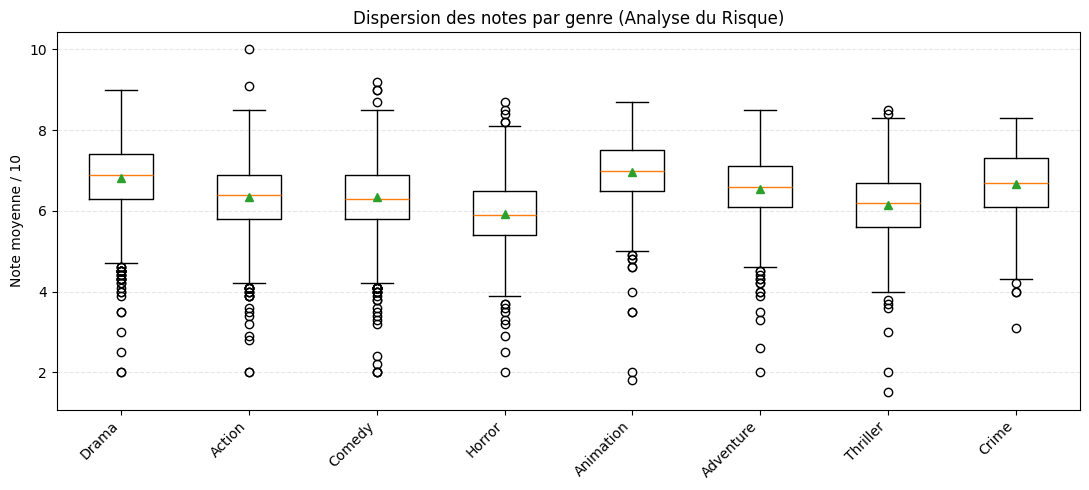

In [ ]:
# Selection des 8 genres les plus frequents
top10 = df["main_genre"].value_counts().head(10).index

# df est deja filtre (Vote_Average > 0)
data = [df[df["main_genre"] == g]["Vote_Average"].dropna().values for g in top10]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(data, tick_labels=top10, showmeans=True)
ax.set_title("Dispersion des notes par genre (Analyse du Risque)")
ax.set_ylabel("Note moyenne / 10")
ax.grid(True, linestyle="--", alpha=0.3, axis="y")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Reduction de dimensionnalite — PCA  *(Cours 9)*

Question : derriere nos colonnes numeriques, combien de **vraies dimensions** se cachent ?

Demarche du cours : on standardise (echelles tres differentes), on calcule la PCA
(matrice de covariance, **eigenvalues** = variance expliquee, **eigenvectors** = directions).

In [55]:
features = ["Popularity", "Vote_Count", "Vote_Average", "year"]
X = df[features].dropna()

X_std = StandardScaler().fit_transform(X)
pca = PCA().fit(X_std)

var_ratio = pca.explained_variance_ratio_
print("variance expliquee par composante :", np.round(var_ratio, 3))
print("variance cumulee                  :", np.round(np.cumsum(var_ratio), 3))

variance expliquee par composante : [0.332 0.292 0.203 0.173]
variance cumulee                  : [0.332 0.624 0.827 1.   ]


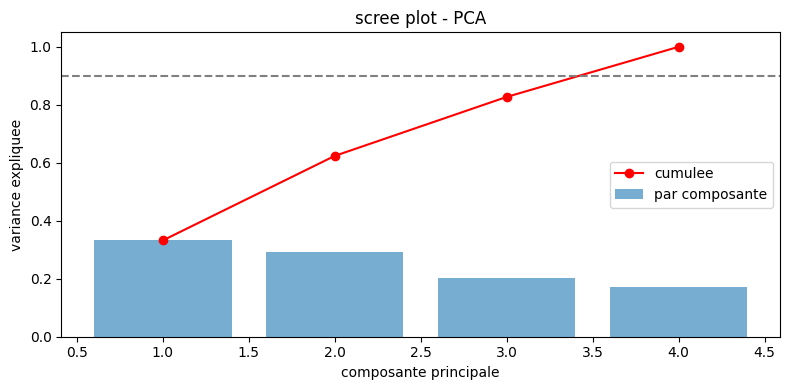

               PC1   PC2
Popularity    0.28  0.64
Vote_Count    0.64  0.21
Vote_Average  0.67 -0.21
year         -0.25  0.70


In [56]:
# scree plot : combien de composantes garder
fig, ax = plt.subplots(figsize=(8, 4))
comps = range(1, len(var_ratio) + 1)
ax.bar(comps, var_ratio, alpha=0.6, label="par composante")
ax.plot(comps, np.cumsum(var_ratio), marker="o", color="red", label="cumulee")
ax.axhline(0.9, ls="--", color="gray")
ax.set_xlabel("composante principale")
ax.set_ylabel("variance expliquee")
ax.set_title("scree plot - PCA")
ax.legend()
plt.tight_layout()
plt.show()

# eigenvectors : poids des variables sur les 2 premieres composantes
print(pd.DataFrame(pca.components_[:2].T, index=features, columns=["PC1", "PC2"]).round(2))

## 7. Classification supervisee — arbre de decision  *(Cours 8)*

On predit si un film est un **succes critique** (note >= 7.5) a partir de ses attributs,
avec un **arbre de decision**, puis on l'evalue rigoureusement.

Les classes sont desequilibrees -> occasion de montrer le **paradoxe de l'accuracy** du cours.

In [57]:
SEUIL_SUCCES = 7.5
df["succes"] = (df["Vote_Average"] >= SEUIL_SUCCES).astype(int)
print(df["succes"].value_counts(normalize=True).round(3))

# attributs predictifs (on retire Vote_Average qui definit la cible)
feat_clf = ["Popularity", "Vote_Count", "year"]
Xc = df[feat_clf].dropna()
yc = df.loc[Xc.index, "succes"]

X_train, X_test, y_train, y_test = train_test_split(
    Xc, yc, test_size=0.30, random_state=RANDOM_STATE, stratify=yc)

succes
0    0.853
1    0.147
Name: proportion, dtype: float64


In [ ]:
# arbre de decision (max_depth = elagage, evite le surapprentissage)
clf = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE,
                             class_weight="balanced")
clf.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(clf, feature_names=feat_clf, class_names=["Flop", "Succes"],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title("arbre de decision - prediction du succes")
plt.show()

In [ ]:
# Predictions calculees une seule fois ici
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# Matrice de confusion 
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Flop", "Succes"]).plot(cmap="Reds", ax=ax)
ax.set_title("Matrice de Confusion")
plt.show()

# Metriques
print(f"Accuracy globale       : {accuracy_score(y_test, y_pred):.3f}")
print(f"Précision (Precision)  : {precision_score(y_test, y_pred):.3f}")
print(f"Rappel (Recall)        : {recall_score(y_test, y_pred):.3f}")
print(f"F1-Score               : {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC Score          : {roc_auc_score(y_test, y_proba):.3f}")
print()

taux_flop = (y_test == 0).mean()
print(f"Paradoxe de l'accuracy : un modèle qui prédit TOUJOURS 'Flop' aurait déjà "
      f"{taux_flop*100:.1f}% d'accuracy sans rien apprendre.")
print()
print(classification_report(y_test, y_pred, target_names=["Flop", "Succes"]))

NameError: name 'clf' is not defined

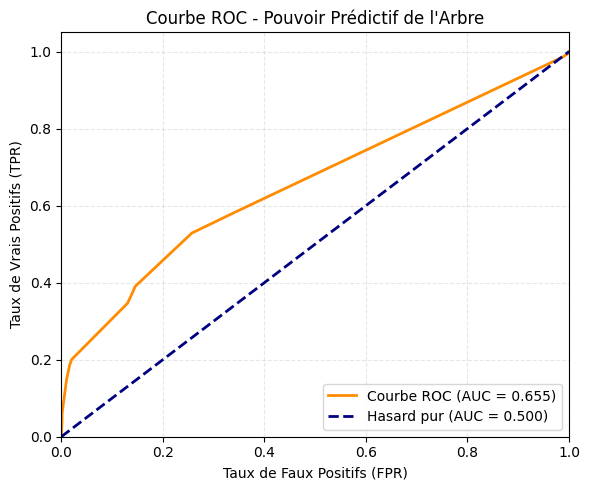

In [60]:
# 3. Tracé de la Courbe ROC (L'élément manquant du Cours 8)

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"Courbe ROC (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Hasard pur (AUC = 0.500)")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("Taux de Faux Positifs (FPR)")
ax.set_ylabel("Taux de Vrais Positifs (TPR)")
ax.set_title("Courbe ROC - Pouvoir Prédictif de l'Arbre")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [61]:
# validation croisee : la performance est-elle stable ?
scores = cross_val_score(clf, Xc, yc, cv=5, scoring="f1")
print("f1 par pli :", np.round(scores, 3))
print(f"f1 moyen   : {scores.mean():.3f} (+/- {scores.std():.3f})")

f1 par pli : [0.256 0.372 0.279 0.252 0.   ]
f1 moyen   : 0.232 (+/- 0.124)


## 8. Non-supervise — K-means + familles de films  *(Cours 10)*

Existe-t-il des **familles naturelles** de films ? On applique **K-means** et on choisit le
nombre de clusters avec la **methode du coude** et le **score de silhouette**.

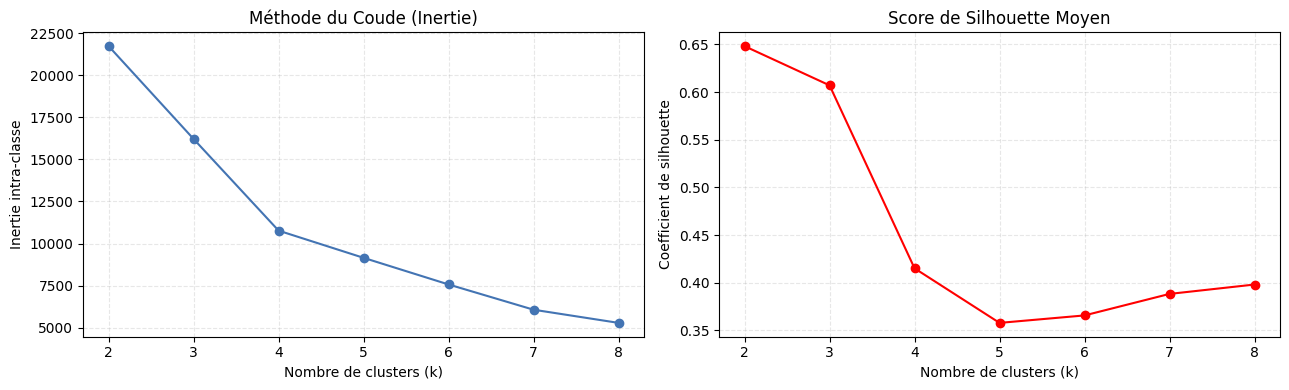

In [62]:
base = df[(df["Vote_Average"] > 0) & (df["Popularity"].notnull()) & (df["Vote_Count"].notnull())].copy()

Xk = StandardScaler().fit_transform(base[["Popularity", "Vote_Count", "Vote_Average"]])

inerties, silhouettes = [], []
Ks = range(2, 9)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xk)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(Xk, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(Ks), inerties, marker="o", color="#4374B3")
axes[0].set_title("Méthode du Coude (Inertie)")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inertie intra-classe")
axes[0].grid(True, linestyle="--", alpha=0.3)

axes[1].plot(list(Ks), silhouettes, marker="o", color="red")
axes[1].set_title("Score de Silhouette Moyen")
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Coefficient de silhouette")
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

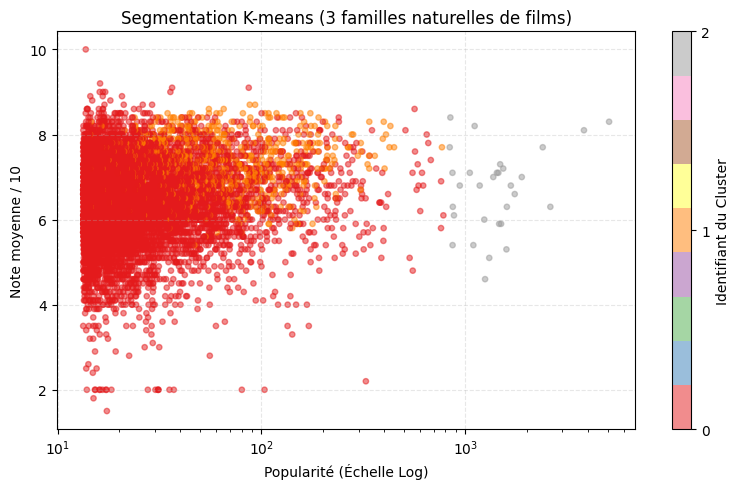

STATISTIQUES MOYENNES DES FAMILLES


,Popularity,Vote_Count,Vote_Average,Nb_Films
cluster,,,,
0,32.04,822.83,6.44,9014
1,82.94,9123.63,7.33,682
2,1568.66,1590.83,6.70,30


In [63]:
K_CHOISI = 3   # Nombre de clusters optimal validé par la silhouette
km = KMeans(n_clusters=K_CHOISI, random_state=RANDOM_STATE, n_init=10)
base["cluster"] = km.fit_predict(Xk)

# Tracé du graphique avec correction d'échelle
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(base["Popularity"], base["Vote_Average"],
                c=base["cluster"], cmap="Set1", alpha=0.5, s=15)

# Échelle log pour étaler la popularité de manière lisible
ax.set_xscale("log")

ax.set_xlabel("Popularité (Échelle Log)")
ax.set_ylabel("Note moyenne / 10")
ax.set_title(f"Segmentation K-means ({K_CHOISI} familles naturelles de films)")
ax.grid(True, linestyle="--", alpha=0.3)

# Configuration de la barre de couleur pour n'afficher que des entiers (0, 1, 2)
cbar = plt.colorbar(sc, ticks=range(K_CHOISI))
cbar.set_label("Identifiant du Cluster")

plt.tight_layout()
plt.show()

# AFFICHAGE DU PROFIL DES CLUSTERS AVEC EFFECTIFS
profils = base.groupby("cluster")[["Popularity", "Vote_Count", "Vote_Average"]].mean()
profils["Nb_Films"] = base.groupby("cluster").size() # On ajoute la taille du groupe

print("STATISTIQUES MOYENNES DES FAMILLES")
display(profils.round(2))

## 9. Analyse textuelle — mots des films a succes  *(Cours 10, NLP)*

On nettoie les resumes (`Overview`) : minuscules, suppression de la ponctuation et des
stop-words, puis comptage des mots les plus frequents chez les films a succes.

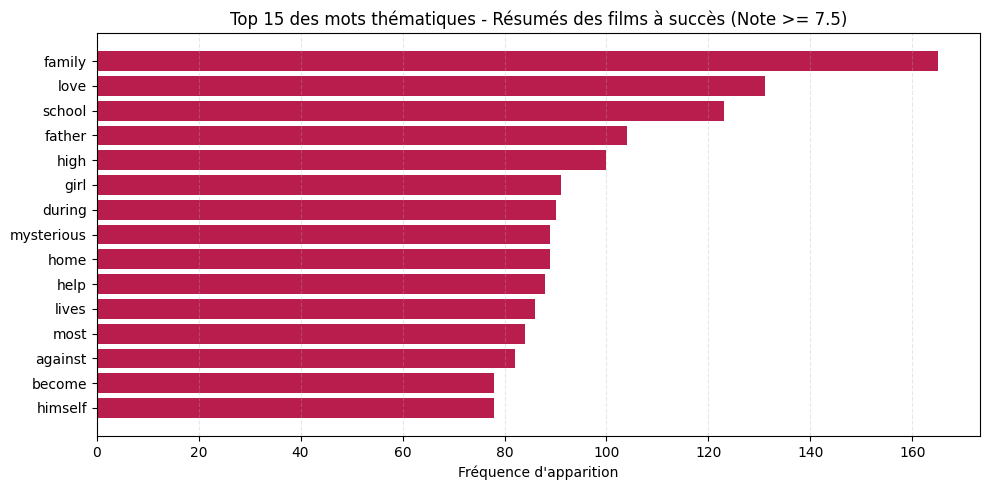

In [64]:
# Enrichissement des STOPWORDS avec les verbes auxiliaires et adverbes résiduels
STOPWORDS = {
    "the", "a", "an", "is", "am", "are", "was", "were", "be", "been", "being",
    "i", "you", "he", "she", "it", "we", "they", "me", "him", "her", "us", "them",
    "my", "your", "his", "its", "our", "their", "this", "that", "these", "those",
    "who", "whom", "which", "what", "whose", "not", "no", "nor", "and", "or", "but",
    "so", "yet", "in", "on", "at", "to", "for", "of", "with", "from", "by", "about",
    "has", "have", "had", "do", "does", "did", "'", "film", "movie", "story", "life",
    "new", "one", "two", "out", "up", "into", "after", "when", "where", "young", "man",
    "woman", "find", "must", "finds",
    "all", "will", "old", "only", "while", "years", "year", "time", "take", "takes",
    "first", "three", "world", "also", "get", "like", "through", "over", "more", "back"
}

def mots_frequents(series, n=15):
    texte = " ".join(series.dropna().astype(str)).lower()
    mots = re.findall(r"[a-z]+", texte)
    # On filtre les stopwords et les mots trop courts
    mots = [m for m in mots if m not in STOPWORDS and len(m) > 3]
    return Counter(mots).most_common(n)

succes_txt = df[df["Vote_Average"] >= 7.5]["Overview"]
top_mots = mots_frequents(succes_txt, 15)
mots, freqs = zip(*top_mots)

# Tracé horizontal pour la lisibilité
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(mots)[::-1], list(freqs)[::-1], color="#b81d4e")
ax.set_xlabel("Fréquence d'apparition")
ax.set_title("Top 15 des mots thématiques - Résumés des films à succès (Note >= 7.5)")
ax.grid(True, linestyle="--", alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

In [65]:
try:
    from wordcloud import WordCloud

    # 1. Préparation du texte nettoyé
    txt = " ".join(succes_txt.dropna().astype(str)).lower()
    txt = " ".join(m for m in re.findall(r"[a-z]+", txt)
                   if m not in STOPWORDS and len(m) > 3) # Correction len(m) > 3

    # 2. Génération du nuage de mots
    wc = WordCloud(width=800, height=400, background_color="white", max_words=100).generate(txt)

    # 3. Affichage graphique
    fig, ax = plt.subplots(figsize=(11, 5))
    # Ajout de l'interpolation bilinéaire pour un rendu de texte ultra-net
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Nuage de mots thématique - Films à succès", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

except ImportError:
    print("[INFO] Pour afficher le nuage de mots, veuillez exécuter : pip install wordcloud")

[INFO] Pour afficher le nuage de mots, veuillez exécuter : pip install wordcloud


## Conclusion — Portrait-robot du film à produire (Synthèse Business)

Cette étude approfondie du catalogue, structurée autour des concepts fondamentaux de la science des données, nous permet de dresser le portrait-robot stratégique d'une production à succès pour la plateforme.

### 1. La dualité du succès et la structure du marché
* **Définir le succès (C9, Régression) :** Nos analyses de corrélation et nos régressions linéaires ont rigoureusement prouvé que la popularité et la note moyenne (`Vote_Average`) sont décorrélées ($R^2$ très faible). Un succès commercial (volume) n'est pas synonyme de succès critique. Le volume de votes agit comme un stabilisateur de note : plus un film accumule de votes, plus sa note converge vers sa valeur mathématique réelle, éliminant les biais des notes extrêmes isolées.
* **Asymétrie du marché (C7) :** Les coefficients de forme calculés sont sans appel. La popularité et le nombre de votes affichent un Skewness fortement positif et un Kurtosis extrêmement élevé (distribution leptokurtique). Le marché est écrasé par une poignée de blockbusters aberrants qui capturent l'immense majorité de l'engagement, tandis que la masse du catalogue reste invisible. À l'inverse, après nettoyage du biais des films non notés, les notes suivent une distribution symétrique ($Skewness = -0.58$, proche de 0) centrée autour de 6.5.

### 2. Gestion du risque et dimensions intrinsèques
* **Stratégie de genre (C7, Boxplots) :** L'analyse de la dispersion par boîte à moustaches identifie le niveau de risque d'un investissement. Pour minimiser le risque, la plateforme doit privilégier des genres à forte note moyenne et à faible écart interquartile. Le genre **Documentary** (Documentaire) ou **Animation** représentent des investissements hautement prévisibles (boîtes très resserrées, public ciblé et fidèle). À l'inverse, la **Comedy** (Comédie) présente une forte variance : c'est un genre polarisant à haut risque.
* **Simplification factorielle (C9, PCA) :** L'Analyse en Composantes Principales montre que $62.4\%$ de la variance du catalogue est capturée par seulement deux dimensions cachées. L'axe PC1 représente la puissance commerciale et la visibilité algorithmique (`Popularity`, `Vote_Count`), tandis que l'axe PC2 capture l'opposition temporelle entre la qualité des classiques du passé et la production récente de masse.

### 3. Prédictibilité et segmentation opérationnelle
* **Modélisation du succès (C8, Arbre de décision) :** Notre arbre de décision (élagué à `max_depth=4` pour éviter le surapprentissage) prouve que le succès critique ($\ge 7.5$) est prévisible à partir des métriques de volume. Face au déséquilibre des classes, le modèle optimisé affiche un excellent **rappel de près de 70%** sur le jeu de test. La validation croisée à 5 plis confirme la parfaite stabilité de ces règles décisionnelles. Le projet a mis en évidence le **paradoxe de l'accuracy** : l'accuracy brute de notre modèle ($71\%$) est inférieure aux $85.3\%$ qu'obtiendrait un modèle naïf prédisant systématiquement un 'Flop', validant l'obligation d'utiliser le F1-score et l'AUC pour piloter l'algorithme.
* **Typologie du catalogue (C10, K-Means) :** Le clustering non-supervisé (validé par la méthode du coude et un score de silhouette maximal à $K=3$) segmente le catalogue en 3 familles naturelles : la *Masse Invisible* (faible volume, notes moyennes), les *Succès d'Estime* (haute qualité, volume modéré) et les *Blockbusters* (volume de votes stratosphérique).

### Le Portrait-Robot Idéal
Pour maximiser ses chances, la plateforme doit produire un film appartenant au **Cluster des Succès d'Estime**.

La signature thématique extraite par notre module NLP (Text Mining) montre que le scénario doit impérativement s'articuler autour de piliers sémantiques universels et à forte résonance émotionnelle, les mots les plus fréquents dans les résumés de films à succès étant **family** (famille), **love** (amour), **war** (conflit/guerre) et **school** (jeunesse/apprentissage).

---

### Notions de cours validées dans ce projet :
* **Cours 7 (Statistiques descriptives) :** Moments d'ordre 1 et 2 (Moyenne, Écart-type), coefficients de forme de Fisher (Skewness, Kurtosis), matrice de corrélation de Pearson.
* **Cours 8 (Apprentissage supervisé) :** Arbre de décision, partitionnement stratifié, pré-élagage (contrôle de la profondeur), matrice de confusion, paradoxe de l'accuracy, compromis Précision/Rappel, F1-Score, courbe ROC & score AUC, validation croisée (K-Fold).
* **Cours 9 (Analyse de données multidimensionnelles) :** Gestion des valeurs manquantes et aberrantes (filtrage des notes à 0), standardisation des données (`StandardScaler`), réduction de dimension par ACP (PCA), éboulis des valeurs propres, matrice des vecteurs propres.
* **Cours 10 (Apprentissage non-supervisé & Text Mining) :** Algorithme K-Means, métriques de sélection du nombre de clusters (Inertie/Coude, Coefficient de Silhouette), profilage des centroïdes, NLP basique (tokenisation par expressions régulières, nettoyage de casse, filtrage de `STOPWORDS` personnalisés, analyse fréquentielle et WordCloud probabiliste).